# Ishihara Career Screening

In [1]:
import json
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

from xgboost import XGBClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt


In [2]:
df = pd.read_excel("BWPDUM300_output_updated.xlsx")

X = df.drop("Label", axis=1)
y = df["Label"]

print(df.shape)


(313, 18)


## Eksplorasi Data (EDA)

### Statistika deskriptif variabel numerik

In [3]:
# Statistika deskriptif untuk variabel numerik
numeric_cols = df.select_dtypes(include="number").columns.tolist()
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Persentase nilai identifikasi warna,313.0,67.268019,22.107824,9.09,54.55,63.64,90.91,100.0
Kemampuan identifikasi Warna,313.0,23.961661,5.195394,7.00,21.00,22.00,26.00,35.0
R,313.0,15.769968,4.894214,6.00,12.00,17.00,20.00,25.0
I,313.0,17.792332,3.597320,7.00,15.00,18.00,21.00,25.0
A,313.0,17.194888,4.209693,7.00,14.00,17.00,21.00,25.0
S,313.0,18.444089,3.326887,7.00,17.00,18.00,21.00,25.0
E,313.0,18.047923,3.389407,6.00,16.00,18.00,21.00,25.0
C,313.0,18.546326,3.737191,7.00,16.00,19.00,22.00,25.0
ColorReq,313.0,36.421725,10.612090,18.00,29.00,37.00,41.00,75.0


### Distribusi kelas target

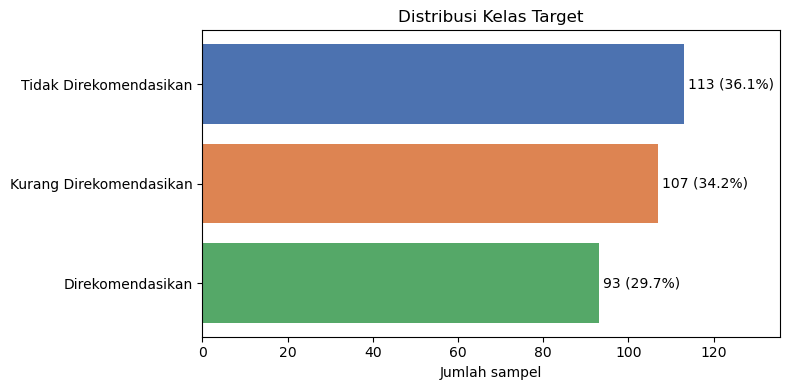

In [4]:
# Distribusi kelas target
class_counts = df["Label"].value_counts()
class_pct = class_counts / class_counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    class_counts.index,
    class_counts.values,
    color=["#4C72B0", "#DD8452", "#55A868"],
)
for bar, pct in zip(bars, class_pct.values):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width())} ({pct:.1f}%)",
        ha="left",
        va="center",
    )
ax.set_xlim(0, class_counts.max() * 1.2)
ax.set_title("Distribusi Kelas Target")
ax.set_xlabel("Jumlah sampel")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [5]:
# Split 80/20 (stratified) + LabelEncoder hanya di-fit pada X_train (tidak bocor)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

categorical = [c for c in df.select_dtypes(include="object").columns if c != "Label"]

label_encoders = {}
for col in categorical:
    le = LabelEncoder()
    le.fit(X_train[col].astype(str))
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = X_test[col].astype(str).map(
        lambda v: v if v in le.classes_ else le.classes_[0]
    )
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)


X_train: (250, 17) | X_test: (63, 17)


## Baseline — XGBoost

`XGBClassifier()` murni: 100 pohon, `learning_rate=0.3`, tanpa tuning.


In [ ]:
model_default = XGBClassifier(random_state=42)
model_default.fit(X_train, y_train)

print("Model default dilatih pada X_train.")


Model default (100 pohon, tanpa tuning) dilatih pada X_train.


## Optuna — tuning hyperparameter

In [ ]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 1000),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.5, log=True),
        "subsample": trial.suggest_float("subsample", 0.50, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.50, 1.00),
        "gamma": trial.suggest_float("gamma", 0, 3),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 5, log=True),
        "objective": "multi:softprob",
        "num_class": len(np.unique(y_train)),
        "eval_metric": "mlogloss",
        "early_stopping_rounds": 30,   # xgboost 3.x: parameter konstruktor
        "random_state": 42,
        "n_jobs": -1,
    }

    model = XGBClassifier(**params)

    rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
    scores = []
    for tr_idx, va_idx in rkf.split(X_train, y_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train[tr_idx], y_train[va_idx]

        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
        scores.append(accuracy_score(y_va, model.predict(X_va)))

    return float(np.mean(scores))


In [8]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=150)

best_params = study.best_params
best_params.update({
    "objective": "multi:softprob",
    "num_class": len(np.unique(y_train)),
    "eval_metric": "mlogloss",
    "early_stopping_rounds": 30,
    "random_state": 42,
    "n_jobs": -1,
})

print(f"Best CV accuracy (repeated 5x3-fold): {study.best_value:.4f}")
print("\nBest hyperparameters:")
print(json.dumps(best_params, indent=2, default=str))


Best CV accuracy (repeated 5x3-fold): 0.9173

Best hyperparameters:
{
  "n_estimators": 967,
  "max_depth": 10,
  "learning_rate": 0.10366175525103115,
  "subsample": 0.7816171323302469,
  "colsample_bytree": 0.9682237536043127,
  "gamma": 0.6653757568622848,
  "min_child_weight": 1,
  "reg_alpha": 0.0002929577530148676,
  "reg_lambda": 0.08733770916626808,
  "objective": "multi:softprob",
  "num_class": 3,
  "eval_metric": "mlogloss",
  "early_stopping_rounds": 30,
  "random_state": 42,
  "n_jobs": -1
}


### Refit model final (Optuna)

1. Probe pada 10% holdout untuk mencari **jumlah pohon optimal** (early stopping).
2. Refit pada **seluruh `X_train`** (250 baris) dengan jumlah pohon tersebut
   → memakai semua data, tanpa early stopping.
3. `X_test` (63 sampel) hanya dipakai sebagai sanity check model final — **bukan** untuk
   membandingkan model, karena 63 sampel terlalu kecil untuk itu.


In [9]:
X_probe, X_early, y_probe, y_early = train_test_split(
    X_train, y_train, test_size=0.10, random_state=42, stratify=y_train
)

probe = XGBClassifier(**best_params)
probe.fit(X_probe, y_probe, eval_set=[(X_early, y_early)], verbose=False)

n_optimal = probe.best_iteration + 1
print("Jumlah pohon optimal:", n_optimal)

final_params = dict(best_params)
final_params.pop("early_stopping_rounds", None)
final_params["n_estimators"] = n_optimal

model_optuna = XGBClassifier(**final_params)
model_optuna.fit(X_train, y_train)

acc_test = accuracy_score(y_test, model_optuna.predict(X_test))
print(f"Akurasi model final pada X_test (sanity check): {acc_test:.4f}")


Jumlah pohon optimal: 95
Akurasi model final pada X_test (sanity check): 0.9683


## Perbandingan — XGBoost default vs XGBoost + Optuna



In [10]:
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)


def _fold_metrics(y_true, y_pred):
    return (
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average="weighted", zero_division=0),
        recall_score(y_true, y_pred, average="weighted", zero_division=0),
        f1_score(y_true, y_pred, average="weighted", zero_division=0),
    )


d_metrics, o_metrics = [], []
d_y_true, d_y_pred, o_y_pred = [], [], []
for tr_idx, va_idx in rskf.split(X_train, y_train):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    d_model = XGBClassifier(random_state=42)
    d_model.fit(X_tr, y_tr)
    d_pred = d_model.predict(X_va)
    d_metrics.append(_fold_metrics(y_va, d_pred))

    o_model = XGBClassifier(**final_params)
    o_model.fit(X_tr, y_tr)
    o_pred = o_model.predict(X_va)
    o_metrics.append(_fold_metrics(y_va, o_pred))

    d_y_true.append(y_va)
    d_y_pred.append(d_pred)
    o_y_pred.append(o_pred)

d_metrics = np.array(d_metrics)
o_metrics = np.array(o_metrics)

d_y_true = np.concatenate(d_y_true)
d_y_pred = np.concatenate(d_y_pred)
o_y_pred = np.concatenate(o_y_pred)

diff = o_metrics[:, 0] - d_metrics[:, 0]

cv_comparison = pd.DataFrame({
    "Model": ["XGBoost (default)", "XGBoost + Optuna"],
    "Akurasi CV (mean)": np.round([d_metrics[:, 0].mean(), o_metrics[:, 0].mean()], 4),
    "Std CV": np.round([d_metrics[:, 0].std(), o_metrics[:, 0].std()], 4),
})

print(cv_comparison.to_string(index=False))
print(f"\nSelisih (Optuna - default)   : {diff.mean():+.4f}")
print(f"Fold Optuna >= default       : {(diff >= 0).sum()}/{len(diff)}")

cv_full = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "XGBoost (default)": np.round(d_metrics.mean(axis=0), 4),
    "XGBoost + Optuna": np.round(o_metrics.mean(axis=0), 4),
    "Selisih": np.round(o_metrics.mean(axis=0) - d_metrics.mean(axis=0), 4),
})

print("\nMetrik lengkap (rata-rata 50 fold):")
print(cv_full.to_string(index=False))


            Model  Akurasi CV (mean)  Std CV
XGBoost (default)             0.9080  0.0375
 XGBoost + Optuna             0.9104  0.0433

Selisih (Optuna - default)   : +0.0024
Fold Optuna >= default       : 34/50

Metrik lengkap (rata-rata 50 fold):
   Metric  XGBoost (default)  XGBoost + Optuna  Selisih
 Accuracy             0.9080            0.9104   0.0024
Precision             0.9147            0.9151   0.0004
   Recall             0.9080            0.9104   0.0024
 F1-score             0.9080            0.9103   0.0023


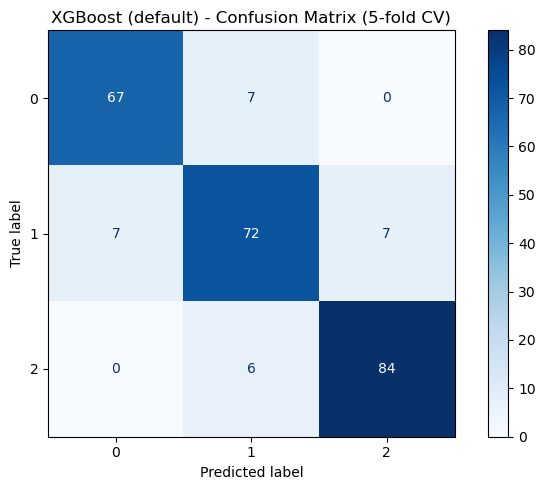

In [11]:
n_repeats = 10
n_cv_samples = len(X_train) * n_repeats  # 2500 prediksi agregat
first_repeat = n_cv_samples // n_repeats  # 250 sampel (1 ulangan 5-fold)

class_names = target_encoder.classes_.astype(str)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    d_y_true[:first_repeat], d_y_pred[:first_repeat], ax=ax,
    cmap="Blues", colorbar=True, values_format="d",
)
ax.set_title("XGBoost (default) - Confusion Matrix (5-fold CV)")
plt.tight_layout()
plt.show()


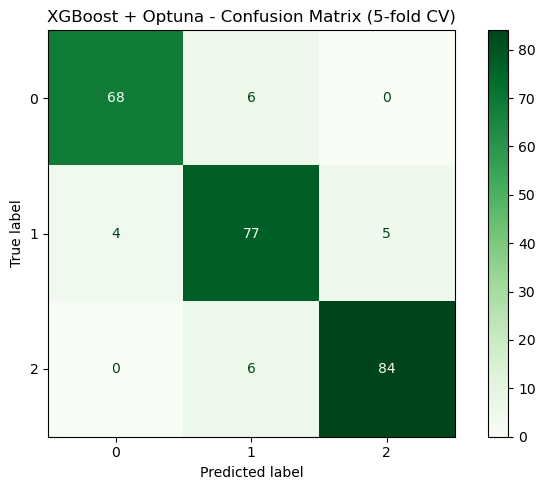

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    d_y_true[:first_repeat], o_y_pred[:first_repeat], ax=ax,
    cmap="Greens", colorbar=True, values_format="d",
)
ax.set_title("XGBoost + Optuna - Confusion Matrix (5-fold CV)")
plt.tight_layout()
plt.show()

In [13]:
print("=== Classification Report - XGBoost (default) ===")
print(classification_report(d_y_true, d_y_pred, target_names=class_names, zero_division=0))

print("\n=== Classification Report - XGBoost + Optuna ===")
print(classification_report(d_y_true, o_y_pred, target_names=class_names, zero_division=0))

=== Classification Report - XGBoost (default) ===
                         precision    recall  f1-score   support

       Direkomendasikan       0.95      0.91      0.93       740
Kurang Direkomendasikan       0.85      0.90      0.87       860
 Tidak Direkomendasikan       0.93      0.92      0.93       900

               accuracy                           0.91      2500
              macro avg       0.91      0.91      0.91      2500
           weighted avg       0.91      0.91      0.91      2500


=== Classification Report - XGBoost + Optuna ===
                         precision    recall  f1-score   support

       Direkomendasikan       0.95      0.93      0.94       740
Kurang Direkomendasikan       0.86      0.88      0.87       860
 Tidak Direkomendasikan       0.93      0.92      0.92       900

               accuracy                           0.91      2500
              macro avg       0.91      0.91      0.91      2500
           weighted avg       0.91      0.91      

## 4) Interpretasi Model dengan SHAP

SHAP (SHapley Additive exPlanations) menjelaskan kontribusi tiap fitur terhadap prediksi.
Model final (`XGBoost + Optuna`) bersifat multi-kelas, sehingga SHAP values dihitung per kelas.

In [14]:
import shap

shap.initjs()

explainer = shap.TreeExplainer(model_optuna)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (63, 17, 3)


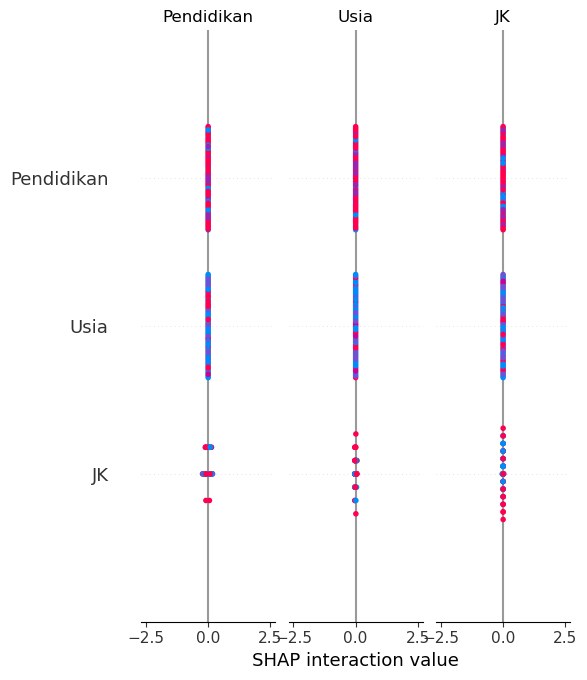

In [15]:
# Ringkasan pengaruh fitur (beeswarm) - semua kelas
shap.summary_plot(shap_values, X_test, show=True)

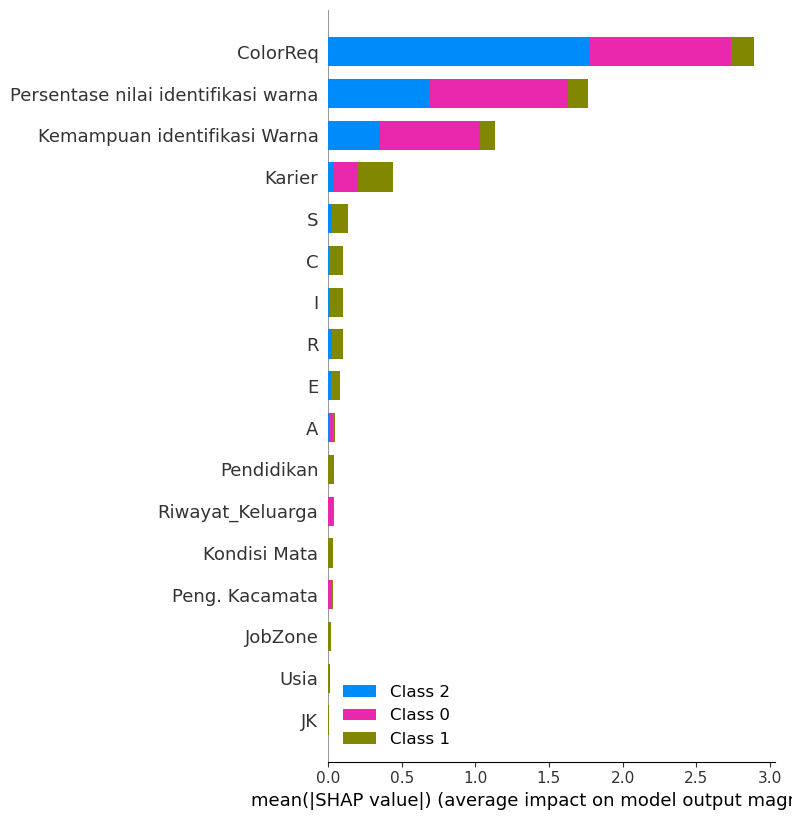

In [16]:
# Feature importance global (bar plot)
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)


Kelas: Direkomendasikan


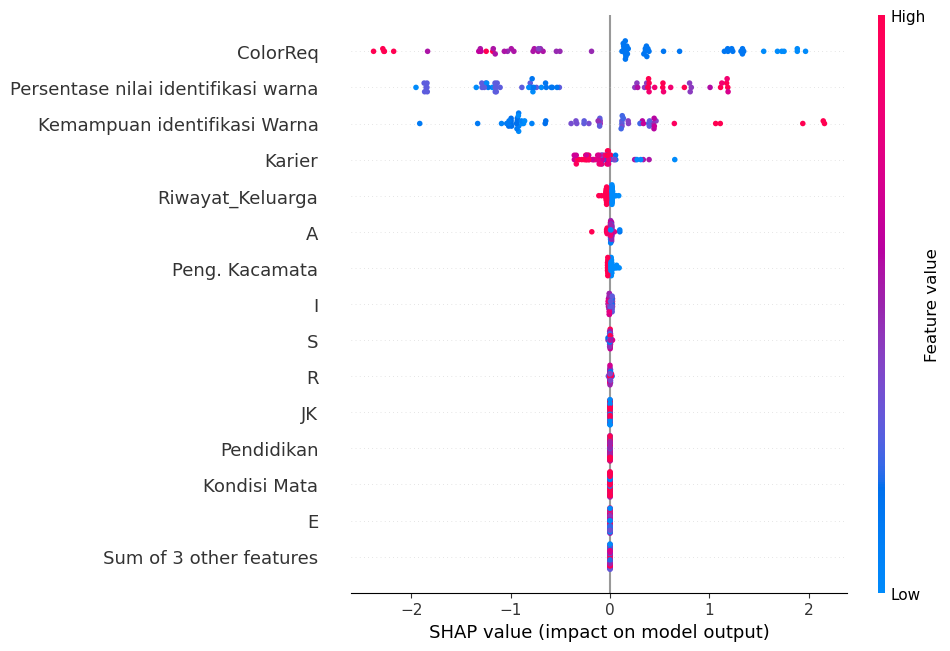


Kelas: Kurang Direkomendasikan


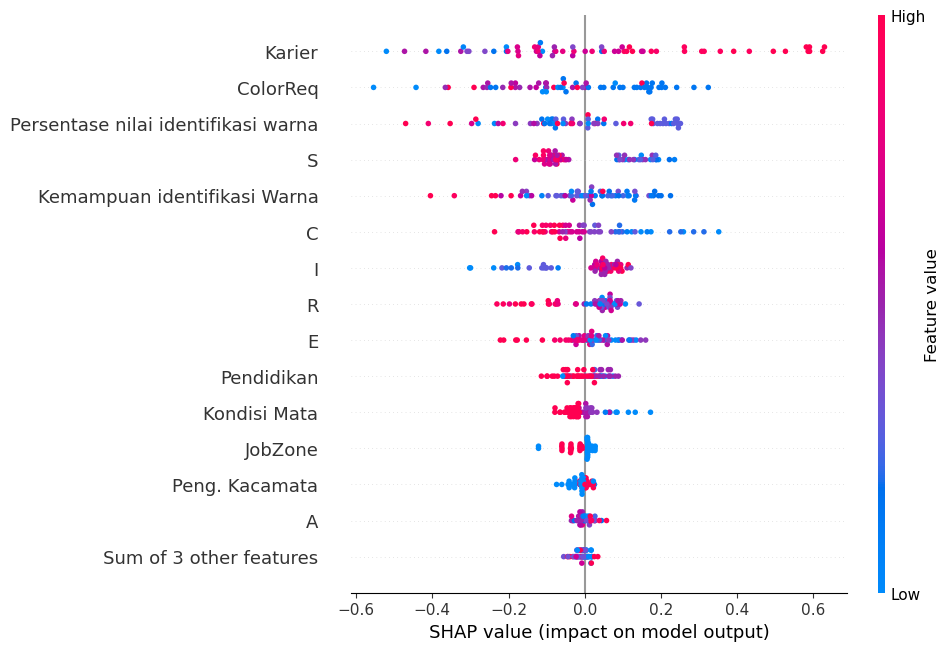


Kelas: Tidak Direkomendasikan


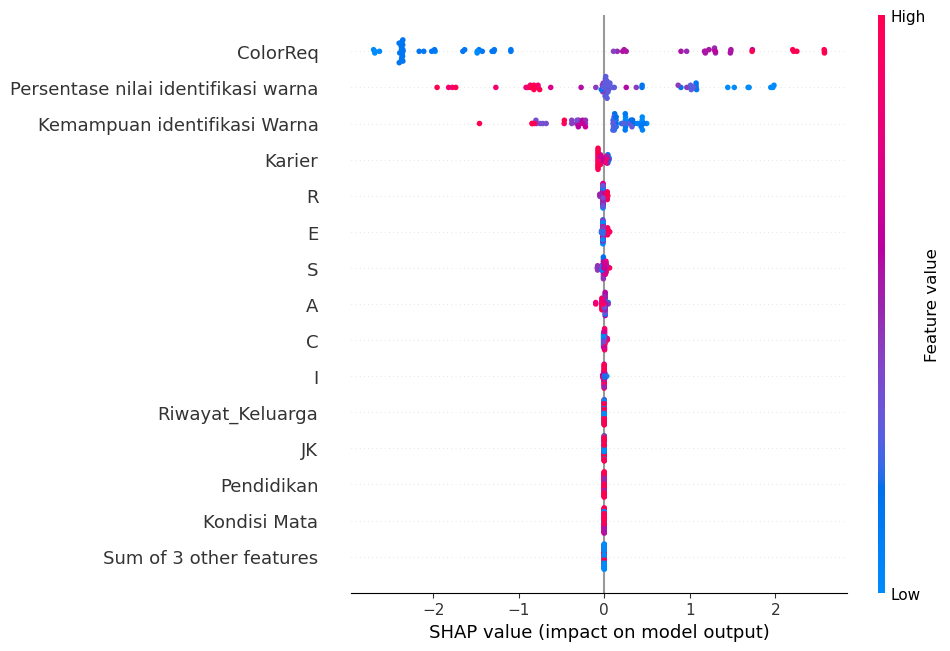

In [17]:
# Beeswarm per kelas
for k, name in enumerate(target_encoder.classes_.astype(str)):
    print(f"\nKelas: {name}")
    shap.plots.beeswarm(
        shap.Explanation(
            values=shap_values[:, :, k],
            data=X_test,
            feature_names=X_test.columns,
        ),
        max_display=15,
    )

In [18]:
import joblib
import os
import shutil

best_model = model_optuna

os.makedirs("pipeline_artifacts", exist_ok=True)
os.makedirs("Ishihara-Career-Screening/src/model", exist_ok=True)

joblib.dump(best_model, "pipeline_artifacts/model_production.pkl")
joblib.dump({
    "label_encoders": label_encoders,
    "target_encoder": target_encoder,
}, "pipeline_artifacts/encoders.pkl")

feature_list = X_train.columns.tolist()
with open("pipeline_artifacts/feature_list.json", "w") as f:
    json.dump(feature_list, f, indent=2)

with open("pipeline_artifacts/best_params.json", "w") as f:
    json.dump(final_params, f, indent=2, default=str)

print("Artifacts saved ke pipeline_artifacts/")


Artifacts saved ke pipeline_artifacts/


In [19]:
src_dir = "pipeline_artifacts"
dst_dir = "Ishihara-Career-Screening/src/model"

for fname in ["model_production.pkl", "encoders.pkl", "feature_list.json", "best_params.json"]:
    shutil.copy2(os.path.join(src_dir, fname), os.path.join(dst_dir, fname))

print("Artifacts dicopy ke Ishihara-Career-Screening/src/model/")


Artifacts dicopy ke Ishihara-Career-Screening/src/model/
